In [1]:
%load_ext autoreload
%autoreload 2
    
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xgcm
import cartopy.crs as ccrs
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import regionate
from pathlib import Path
import warnings
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

warnings.filterwarnings(
    "ignore",
    message=r".*Approximating coordinate system.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message="All-NaN slice encountered",
    category=RuntimeWarning,
    module="dask.array.reductions",
)


In [2]:
from dask.distributed import LocalCluster
cluster = LocalCluster()        
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 6
Total threads: 36,Total memory: 187.53 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38413,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33962,Total threads: 6
Dashboard: /proxy/32974/status,Memory: 31.26 GiB
Nanny: tcp://127.0.0.1:42544,


In [3]:
import cmocean
import cmocean.cm as cmo
model2glodap_names = {'cfc12':'cfc12','cfc11':'cfc11','sf6':'sf6','thetao':'theta','so':'salinity'}
variable_kwargs = {
    'cfc12':{'conversion':1e12/1035,'cmap':'Greens','units':'pmol kg-1'}, #originally mol/m^3
    'cfc11':{'conversion':1e12/1035,'cmap':'PuRd','units':'pmol kg-1'},
    'sf6':{'conversion':1e12/1035 * 1e3,'cmap':'Blues','units':'fmol kg-1'},
    'theta':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'degK','bins':np.arange(-2,35,0.2),'anombins':np.arange(-4,4.05,0.05)},
    'thetao':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'deg C','bins':np.arange(-2,35,0.2),'anombins':np.arange(-4,4.05,0.05)},
    'salinity':{'conversion':1,'cmap':cmocean.cm.haline,'units':'psu','bins':np.arange(32,37,0.05),'anombins':np.arange(-1,1.02,0.02)}
}


In [4]:
def update_transient_tracers(ds): 
    ds["sf6"] = 1 * ds["sf6"] * variable_kwargs["sf6"]["conversion"]
    ds["cfc11"] = 1 * ds["cfc11"] * variable_kwargs["cfc11"]["conversion"]
    ds["cfc12"] = 1 * ds["cfc12"] * variable_kwargs["cfc12"]["conversion"]
    
    ds["sf6"].attrs["units"] = "fmol kg-1"
    ds["cfc11"].attrs["units"] = "pmol kg-1"
    ds["cfc12"].attrs["units"] = "pmol kg-1"
    return ds
    
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/bottom_tracers_yearly.zarr"
ds_bottom = xr.open_mfdataset(ds_path).drop_vars(["lon", "lat"])

ds_bottom = ds_bottom.assign_coords({"lon":1 * ds_bottom["geolon"].compute(), "lat":1 * ds_bottom["geolat"].compute()})
ds_bottom.coords["lon"].values = ds_bottom.coords["lon"].values % 360
ds_bottom = ds_bottom.sel(year = slice(None, 2099))

ds_bottom = update_transient_tracers(ds_bottom)

detection_level = {"cfc11": 0.01, "cfc12": 0.01, "sf6": 0.1}


In [5]:
ds_loc_column = xr.open_dataset("/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/adelie_ross_column_samples.zarr")
ds_loc_column

<xarray.Dataset> Size: 8MB
Dimensions:         (expt: 2, year: 250, z_l: 35, obs_loc: 3, yq: 561, xq: 721)
Coordinates: (12/13)
  * expt            (expt) StringDType() 32B 'control' 'forced'
  * year            (year) int64 2kB 1850 1851 1852 1853 ... 2096 2097 2098 2099
  * z_l             (z_l) float64 280B 2.5 10.0 20.0 ... 5.5e+03 6e+03 6.5e+03
  * obs_loc         (obs_loc) <U8 96B 'adelie' 'ross' 'interior'
    depth           (obs_loc) float32 12B ...
    lat             (obs_loc) float64 24B ...
    ...              ...
    print_name      (obs_loc) <U8 96B ...
    R_km            (obs_loc) float64 24B ...
  * yq              (yq) int64 4kB 0 1 2 3 4 5 6 ... 554 555 556 557 558 559 560
  * xq              (xq) int64 6kB 0 1 2 3 4 5 6 ... 714 715 716 717 718 719 720
    geolat_c        (yq, xq) float64 3MB ...
    geolon_c        (yq, xq) float64 3MB ...
Data variables:
    cfc11           (expt, year, z_l, obs_loc) float32 210kB ...
    cfc12           (expt, year, z_l, obs_loc) float32 210kB ...
    sf6             (expt, year, z_l, obs_loc) float32 210kB ...
    sigma2_offline  (expt, year, z_l, obs_loc) float64 420kB ...
    so              (expt, year, z_l, obs_loc) float32 210kB ...
    thetao          (expt, year, z_l, obs_loc) float32 210kB ...
    z               (expt, year, z_l, obs_loc) float32 210kB ...
Attributes:
    regrid_method:  bilinear

In [6]:
ds_loc = xr.open_dataset("/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/adelie_ross_bottom_samples.zarr")
ds_loc

<xarray.Dataset> Size: 21MB
Dimensions:               (expt: 2, year: 250, obs_loc: 3, yh: 560, xh: 720)
Coordinates: (12/19)
  * expt                  (expt) StringDType() 32B 'control' 'forced'
  * year                  (year) int64 2kB 1850 1851 1852 ... 2097 2098 2099
  * obs_loc               (obs_loc) <U8 96B 'adelie' 'ross' 'interior'
    depth                 (obs_loc) float32 12B ...
    lat                   (obs_loc) float64 24B ...
    lon                   (obs_loc) float64 24B ...
    ...                    ...
    geolon                (yh, xh) float64 3MB ...
    horiz_proximity_mask  (obs_loc, yh, xh) bool 1MB ...
    model_lat             (yh, xh) float64 3MB ...
    model_lon             (yh, xh) float64 3MB ...
    wet                   (yh, xh) float32 2MB ...
    z_l                   float64 8B ...
Data variables:
    cfc11                 (expt, year, obs_loc) float32 6kB ...
    cfc12                 (expt, year, obs_loc) float32 6kB ...
    real_obs_near_loc     (obs_loc, year) float64 6kB ...
    sf6                   (expt, year, obs_loc) float32 6kB ...
    sigma2_offline        (expt, year, obs_loc) float64 12kB ...
    so                    (expt, year, obs_loc) float32 6kB ...
    thetao                (expt, year, obs_loc) float32 6kB ...
    z                     (expt, year, obs_loc) float32 6kB ...

In [7]:
src = "GEBCO_2026_sub_ice.nc"
factor = 10

elev = xr.open_dataset(
    src,
    chunks={"lat": 1000, "lon": 1000},
)["elevation"]

depth = (-elev.astype("float32")).where(elev < 0)

depth_coarse = (
    depth
    .coarsen(lat=factor, lon=factor, boundary="trim")
    .mean()
    .compute()
)

depth_ant = depth_coarse.sel(lat=slice(-90, -50))


In [8]:
depth_src = depth_ant.assign_coords(
    lon=(depth_ant.lon + 360) % 360
).sortby("lon")

depth_src = depth_src.transpose("lat", "lon")

target = xr.Dataset(
    coords={
        "loc": np.arange(ds_loc.sizes["obs_loc"]),
        "lon": ("loc", (ds_loc.lon.values + 360) % 360),
        "lat": ("loc", ds_loc.lat.values),
    }
)

regridder = xe.Regridder(
    depth_src,
    target,
    "nearest_s2d",
    periodic=True,
    locstream_out=True,
    reuse_weights=False,
)

depth_at_locs = regridder(depth_src)

depth_at_locs = depth_at_locs.rename({"loc": "obs_loc"}).assign_coords(
    obs_loc=ds_loc.obs_loc.values,
    lon=("obs_loc", ds_loc.lon.values),
    lat=("obs_loc", ds_loc.lat.values),
)

depth_at_locs

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.13/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


<xarray.DataArray (obs_loc: 3)> Size: 12B
array([ 246.17,  542.65, 3374.03], dtype=float32)
Coordinates:
  * obs_loc  (obs_loc) <U8 96B 'adelie' 'ross' 'interior'
    lon      (obs_loc) float64 24B 142.0 182.1 190.0
    lat      (obs_loc) float64 24B -66.0 -74.0 -67.0
Attributes:
    regrid_method:  nearest_s2d

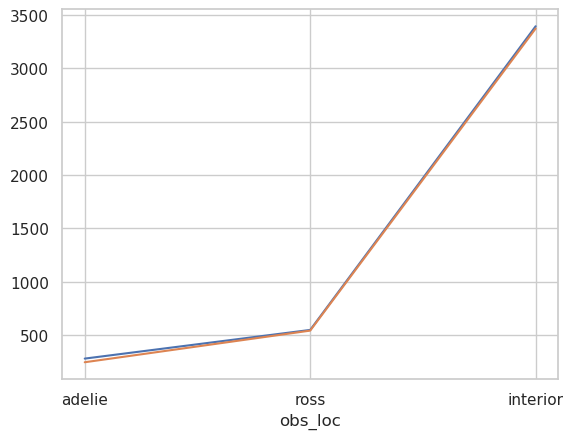

In [9]:
ds_loc.depth.plot(label = "cm4x")
depth_at_locs.plot(label = "gebco")

In [50]:
lat_cut = -50
near_bottom_cut_meters = 1000

cchdo_ds = xr.open_dataset("cchdo_anslope_compiled_data.nc", engine = "h5netcdf")
cchdo_ds = cchdo_ds.where(cchdo_ds.lat <= lat_cut, drop=True)

cchdo_ds["depth"] = np.abs(gsw.z_from_p(cchdo_ds["pressure"], cchdo_ds["lat"]))
cchdo_ds["lon"] = (cchdo_ds["lon"] + 360) % 360

obs = cchdo_ds[["lon", "lat"]]

cast_bottom_dist = abs(cchdo_ds.bottom_depth - cchdo_ds.depth)
gebco_bottom_dist = abs(cchdo_ds.gebco_bottom_depth - cchdo_ds.depth)

cchdo_ds = cchdo_ds.assign_coords(near_bottom_cut=near_bottom_cut_meters)


cchdo_ds["near_bottom"] = ((cast_bottom_dist <= cchdo_ds.near_bottom_cut) | (gebco_bottom_dist <= cchdo_ds.near_bottom_cut))
cchdo_near_bottom = cchdo_ds.where(cchdo_ds.near_bottom, drop=True)
cchdo_near_bottom = cchdo_near_bottom.set_coords(["depth", "near_bottom", "gebco_bottom_depth", "bottom_depth"])
cchdo_near_bottom = cchdo_near_bottom.assign_coords(obs=range(cchdo_near_bottom.sizes["obs"]))

cchdo_near_bottom["cfc11"] = cchdo_near_bottom["cfc11"].where(cchdo_near_bottom["cfc11"] > 0.0)
cchdo_near_bottom["cfc12"] = cchdo_near_bottom["cfc12"].where(cchdo_near_bottom["cfc12"] > 0.0)
cchdo_near_bottom["sf6"] = cchdo_near_bottom["sf6"].where(cchdo_near_bottom["sf6"] > 0.0)

cchdo_near_bottom

<xarray.Dataset> Size: 2MB
Dimensions:             (obs: 18817)
Coordinates:
  * obs                 (obs) int64 151kB 0 1 2 3 4 ... 18813 18814 18815 18816
    bottom_depth        (obs) float64 151kB 3.612e+03 3.612e+03 ... 2.692e+03
    gebco_bottom_depth  (obs) float32 75kB 3.605e+03 3.605e+03 ... 2.813e+03
    depth               (obs) float64 151kB 2.707e+03 2.95e+03 ... 2.03e+03
    near_bottom         (obs) float64 151kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    cast                (obs) float64 151kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    lat                 (obs) float64 151kB -64.61 -64.61 ... -52.01 -50.51
    lon                 (obs) float64 151kB 147.6 147.6 147.6 ... 6.014 6.027
    pressure            (obs) float64 151kB 2.752e+03 3e+03 ... 2.057e+03
    time                (obs) datetime64[ns] 151kB 2004-10-20T00:53:00 ... 19...
    near_bottom_cut     int64 8B 1000
Data variables:
    cfc11               (obs) float64 151kB 0.659 0.794 1.21 ... 0.32 0.24 0.15
    cfc12               (obs) float64 151kB 0.344 0.425 0.632 ... 0.16 0.16 0.1
    salinity            (obs) float64 151kB 34.68 34.68 34.67 ... 34.69 34.73
    sf6                 (obs) float64 151kB 0.042 0.062 0.093 ... nan nan nan
    temperature         (obs) float64 151kB 0.1439 0.0435 ... 0.5413 1.301

In [112]:
def haversine(lon1, lat1, lon2, lat2, R=6371.0):
    lon1, lat1, lon2, lat2 = map(np.deg2rad, [lon1, lat1, lon2, lat2])

    a = (
        np.sin((lat2 - lat1) / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


def gaussian_weight(r_km, dz_m, Lr_km=50, Lz_m=300):
    return np.exp(
        -0.5 * (r_km / Lr_km) ** 2
        -0.5 * (dz_m / Lz_m) ** 2
    )

def uniform_weight(r_km, dz_m, Lr_km=50, Lz_m=300):
    return xr.ones_like(r_km)
    

def weighted_mean(x, w, dim="obs"):
    return (x * w).sum(dim, skipna=True) / w.sum(dim, skipna=True)
    # return x.mean(dim, skipna = True)

def mask_at_obs(mask, obs):
    regridder = xe.Regridder(
        xr.Dataset({"lon": mask.model_lon, "lat": mask.model_lat}),
        xr.Dataset({"lon": obs.lon, "lat": obs.lat}),
        "nearest_s2d",
        locstream_out=True,
    )

    return regridder(mask.astype(float)) > 0.5


def estimate_location(
    obs,
    mask,
    loc,
    Lr_km=50,
    Lz_m=300,
    z_cutoff_m=None,
    lon="lon",
    lat="lat",
    depth="depth",
    dim="obs",
):
    r_km = haversine(obs[lon], obs[lat], loc[lon], loc[lat])
    dz_m = abs(obs[depth] - loc[depth])

    inside = mask_at_obs(mask, obs)

    if z_cutoff_m is not None:
        inside = inside & (dz_m <= z_cutoff_m)

   # w = gaussian_weight(r_km, dz_m, Lr_km=Lr_km, Lz_m=Lz_m)
    w = uniform_weight(r_km, dz_m, Lr_km=Lr_km, Lz_m=Lz_m)
    # w = 1.0
    stats = ["estimate", "n_obs", f"mean_{lon}", f"mean_{lat}", f"mean_{depth}"]
    out = xr.Dataset()

    for name, da in obs.data_vars.items():
        if name in {lon, lat, depth}:
            continue
        if dim not in da.dims:
            continue
        if not np.issubdtype(da.dtype, np.number):
            continue

        ok = inside & np.isfinite(da) & np.isfinite(w)
        ww = w.where(ok)

        out[name] = xr.concat(
            [
                weighted_mean(da, ww, dim),
                ok.sum(dim).astype(float),
                weighted_mean(obs[lon], ww, dim),
                weighted_mean(obs[lat], ww, dim),
                weighted_mean(obs[depth], ww, dim),
            ],
            dim=xr.IndexVariable("stat", stats),
        )

    return out


def estimate_locs_from_sparse_obs(
    obs,
    masks,
    locs,
    Lr_km=50,
    Lz_m=300,
    z_cutoff_m=None,
    loc_dim="obs_loc",
    lon="lon",
    lat="lat",
    depth="depth",
    dim="obs",
):
    out = {}

    for name in locs[loc_dim].values:
        loc = locs.sel({loc_dim: name})

        valid_loc = np.isfinite(
            [float(loc[lon]), float(loc[lat]), float(loc[depth])]
        ).all()

        if not valid_loc:
            raise ValueError(f"Non-finite lon/lat/depth for {loc_dim}={name!r}")

        out[name] = estimate_location(
            obs=obs,
            mask=masks.sel({loc_dim: name}),
            loc=loc,
            Lr_km=Lr_km,
            Lz_m=Lz_m,
            z_cutoff_m=z_cutoff_m[name],
            lon=lon,
            lat=lat,
            depth=depth,
            dim=dim,
        )

    return xr.concat(
        list(out.values()),
        dim=xr.IndexVariable(loc_dim, list(out)),
    )

In [113]:
native_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/transient_tracers_z"
files = ["CM4Xp125_piControl_transient_tracers_z.zarr", "CM4Xp125_historical_transient_tracers_z.zarr", "CM4Xp125_ssp585_transient_tracers_z.zarr"]
full_depth_files = [native_path + "/" + a for a in files]

files = ["CM4Xp125_piControl_transient_tracers_surface.zarr", 
         "CM4Xp125_historical_transient_tracers_surface.zarr", 
         "CM4Xp125_ssp585_transient_tracers_surface.zarr"]
surface_files = [native_path + "/" + a for a in files]

def preprocess(ds):
    if ("year_ctrl" in ds.coords) or ("time_ctrl" in ds.coords):
        # if "time_ctrl" in ds.coords:
        #     ds = ds.reset_coords("year_ctrl", drop=True)
        # else:
        #     ds = ds.reset_coords("time_ctrl", drop=True)
        ds = ds.expand_dims(expt=["control"])
        ds.coords["year"] = ds.coords["year"]
        ds = ds.drop_vars(["year_ctrl"])
    else: 
        ds = ds.expand_dims(expt=["forced"])        
    return ds.sel(yh = slice(None, 180), year = slice(None, 2099))
    
ds_ctrl= xr.open_mfdataset(full_depth_files[0], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")
ds_forced = xr.open_mfdataset(full_depth_files[1:], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")

ds= xr.concat([ds_ctrl, ds_forced], dim = "expt")
ds["z"] = approximate_z_bottom_up(ds, dim="z_l")
ds = ds.drop_vars(["volcello", "thkcello", "sigma2"])
ds = update_transient_tracers(ds)

In [114]:
def interp_1d(q, z, z0):
    ok = np.isfinite(q) & np.isfinite(z)

    if ok.sum() < 2 or not np.isfinite(z0):
        return np.nan

    z, q = z[ok], q[ok]
    order = np.argsort(z)
    z, q = z[order], q[order]

    keep = np.r_[True, np.diff(z) > 0]
    z, q = z[keep], q[keep]

    if z.size < 2:
        return np.nan

    return np.interp(z0, z, q, left=np.nan, right=q[-1])


def interp_depth_var(da, z, z0, zdim="z_l"):
    return xr.apply_ufunc(
        interp_1d, da, z, z0,
        input_core_dims=[[zdim], [zdim], []],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[da.dtype],
    )


names = ["cfc11", "cfc12", "sf6", "sigma2_offline", "so", "thetao", "z"]

masks = ds_loc["horiz_proximity_mask"].sel(yh=slice(None, 180))
ds_subset = ds[names].sel(xh=masks.xh.values, yh=masks.yh.values)

regridder = xe.Regridder(
    ds_subset,
    cchdo_near_bottom,
    "bilinear",
    locstream_out=True,
    periodic=True,
)

cm4x_profiles = regridder(ds_subset).drop_vars(
    ["yq", "xq", "geolat_c", "geolon_c"],
    errors="ignore",
)

cm4x_depth = xr.Dataset()

for name in names:
    cm4x_depth[name] = interp_depth_var(
        cm4x_profiles[name],
        cm4x_profiles["z"],
        cchdo_near_bottom["depth"],
    )

t_obs = (
    cchdo_near_bottom["time"].dt.year
    + (cchdo_near_bottom["time"].dt.dayofyear - 1) / 365.25
)

cm4x_like_cchdo = cm4x_depth.interp(year=t_obs)

cm4x_like_cchdo = cm4x_like_cchdo.assign_coords(
    {
        c: cchdo_near_bottom.coords[c]
        for c in ["obs", "lon", "lat", "depth", "pressure", "time"]
        if c in cchdo_near_bottom.coords
    }
)

for var in ["sf6", "cfc11", "cfc12"]: 
    cm4x_like_cchdo[var] = cm4x_like_cchdo[var].where(cchdo_sparse[var].notnull())
    cm4x_like_cchdo[var] =  cm4x_like_cchdo[var].where( cm4x_like_cchdo[var] > 0.001)
    
cm4x_like_cchdo = cm4x_like_cchdo.compute()

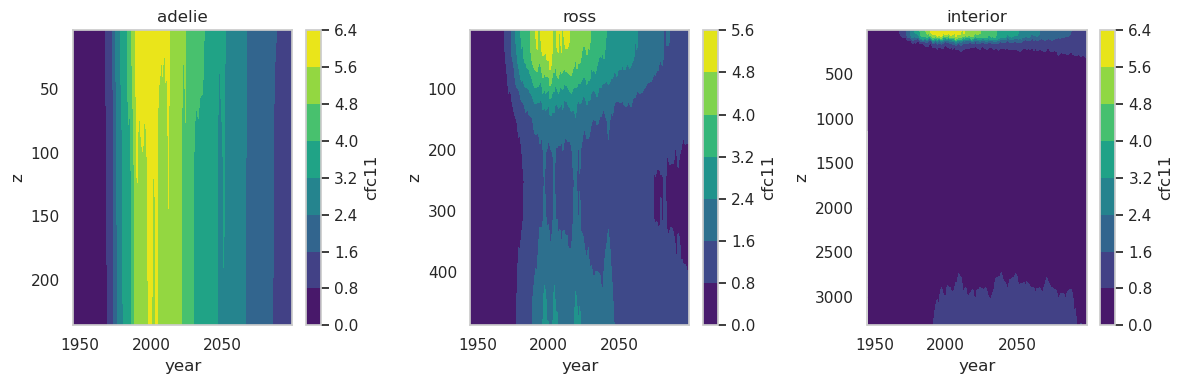

In [115]:
fig, ax = plt.subplots(1, 3, figsize = (12, 4))

for (i, source) in enumerate(ds_loc_column.obs_loc.values): 
    tmp = ds_loc_column.sel(obs_loc = source, expt = "control").set_coords("z")["cfc11"]
    tmp = tmp.where(tmp["z"].notnull(), drop = True)
    tmp = tmp.where(tmp.notnull(), drop = True)
    tmp.plot.contourf(ax = ax[i],  x = "year", y = "z")
    ax[i].invert_yaxis()
    ax[i].set_title(source)

fig.tight_layout()

In [116]:
z_cutoff = {"adelie":50, "ross": 100, "interior" : 150}
locs = ds_loc[["lon", "lat", "depth"]].set_coords(["lon", "lat", "depth"])

cchdo_sparse = cchdo_near_bottom.drop_dims("obs_loc", errors="ignore")
cchdo_sparse = cchdo_sparse.assign_coords(year=cchdo_sparse["time"].dt.year)

cm4x_like_cchdo = cm4x_like_cchdo.drop_dims("obs_loc", errors="ignore")
cm4x_like_cchdo = cm4x_like_cchdo.assign_coords(year=cchdo_sparse["time"].dt.year)

estimate_one_year = lambda ds_y: estimate_locs_from_sparse_obs(
    obs=ds_y.drop_vars("year", errors="ignore"),
    masks=masks.drop_vars(["lon", "lat"]),
    locs=locs,
    z_cutoff_m=z_cutoff,
)

estimate_from_cchdo = cchdo_sparse.groupby("year").map(estimate_one_year)
estimate_from_model = cm4x_like_cchdo.where(cm4x_like_cchdo.notnull()).groupby("year").map(estimate_one_year)


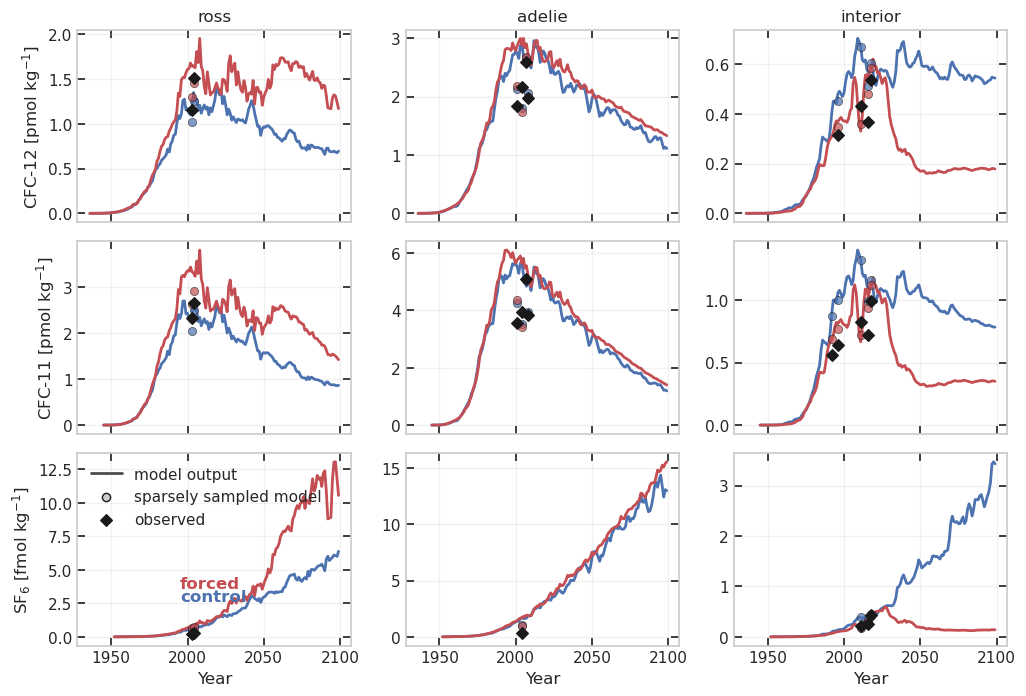

In [117]:
def plot_one_panel(
    ax, var, loc,
    true, model, obs,
    ylabel="",
    title="",
    show_legend=False,
    show_text=False,
    colors={"control": "b", "forced": "r"},
):
    for expt, color in colors.items():
        true_series = true[var].sel(expt=expt, obs_loc=loc)
        model_series = model[var].sel(expt=expt, obs_loc=loc, stat="estimate")

        ax.plot(true.year, true_series, color=color, lw=2)
        ax.scatter(model.year, model_series, color=color, s=35, ec="k", lw=0.5, zorder=3, alpha = 0.7)

        if show_text:
            ax.text(
                1995, true_series.isel(year=-50),
                expt,
                color=color,
                weight="bold",
                va="center",
            )

    obs_series = obs[var].sel(obs_loc=loc, stat="estimate")
    ax.scatter(obs.year, obs_series, color="k", marker="D", s=35, zorder=4)

    ax.set(title=title, xlabel="Year", ylabel=ylabel)
    ax.grid(alpha=0.25)
    ax.tick_params(direction="in", top=True, right=True, left = True, bottom = True)

    if show_legend:
        ax.plot([], [], color="0.3", lw=2, label="model output")
        ax.scatter([], [], color="0.8", ec="k", s=35, label="sparsely sampled model")
        ax.scatter([], [], color="k", marker="D", s=35, label="observed")
        ax.legend(frameon=False, loc="upper left")


tracers = {
    "cfc12": r"CFC-12 [pmol kg$^{-1}$]",

    "cfc11": r"CFC-11 [pmol kg$^{-1}$]",
    "sf6": r"SF$_6$ [fmol kg$^{-1}$]",
}

locations = ["ross", "adelie", "interior"]

n_tracers = len(tracers)
n_locations = len(locations)

fig, axes = plt.subplots(
    n_tracers, n_locations,
    figsize=(12, 8),
    sharex=True,
    sharey=False,
)

for row, (var, label) in enumerate(tracers.items()):
    for col, loc in enumerate(locations):
        is_left_col = col == 0
        is_top_row = row == 0
        is_legend_panel = row == 2 and col == 0

        plot_one_panel(
            axes[row, col],
            var=var,
            loc=loc,
            true=ds_loc,
            model=estimate_from_model,
            obs=estimate_from_cchdo,
            ylabel=label if is_left_col else "",
            title=loc if is_top_row else "",
            show_legend=is_legend_panel,
            show_text=is_legend_panel,
        )

for ax in axes[:-1, :].ravel():
    ax.set_xlabel("")
fig.subplots_adjust(    hspace = 0.1,wspace = 0.2)